<a href="https://colab.research.google.com/github/reza-pishva/RNN-projects/blob/main/Clustering/Lube%20Oil%20System/DBSCAN/clustering_lube_oil_g11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
import pandas as pd
from IPython.display import display, HTML
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
import matplotlib.cm as cm
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import silhouette_score, silhouette_samples
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Lambda, Layer
from tensorflow.keras.losses import mse
from sklearn.decomposition import PCA
from tensorflow.keras import backend as K
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import scipy.cluster.hierarchy as sch
import warnings # Ignore specific warnings
warnings.filterwarnings("ignore")

In [47]:
df1 = pd.read_excel('output_lube_oil_g11.xlsx')

In [48]:
df1.head(10)

,AssetID_8341,AssetID_8342,AssetID_8343,AssetID_8344,AssetID_8346,AssetID_9286,AssetID_9287,date
0,0.23,12.30,66.0,-205.0,7.9,NaN,NaN,2021-03-17 09:16:14
1,0.21,12.30,63.0,-205.0,7.9,8.0,1.45,2021-03-18 08:44:03
2,0.21,12.30,62.0,-205.0,0.0,8.1,1.38,2021-03-19 09:01:53
3,0.25,12.30,61.0,-200.0,7.8,8.0,1.38,2021-03-20 17:49:02
4,0.23,12.30,58.0,-205.0,7.8,8.1,1.38,2021-03-20 20:05:58
5,0.21,12.30,62.0,-205.0,7.8,8.1,1.38,2021-03-20 22:43:37
6,0.21,12.30,62.0,-205.0,7.8,8.1,1.38,2021-03-21 02:05:28
7,0.23,0.23,64.0,-240.0,8.0,NaN,NaN,2021-03-21 05:17:54
8,NaN,NaN,62.0,-210.0,8.0,NaN,NaN,2021-03-21 08:10:07
9,0.23,NaN,65.0,-210.0,7.8,NaN,NaN,2021-03-21 10:45:51


In [49]:
df1.columns

Index(['AssetID_8341', 'AssetID_8342', 'AssetID_8343', 'AssetID_8344',
       'AssetID_8346', 'AssetID_9286', 'AssetID_9287', 'date'],
      dtype='object')

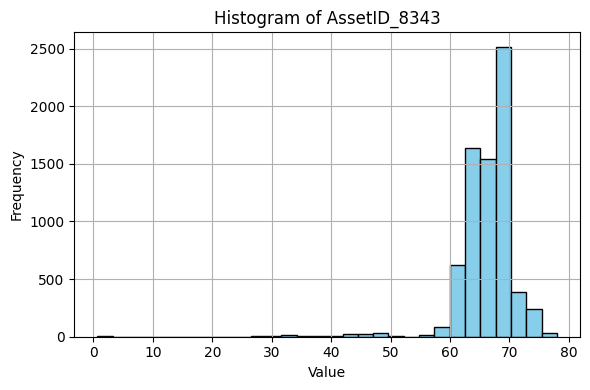

In [50]:
# رسم هیستوگرام برای AssetID_8343
plt.figure(figsize=(6, 4))
plt.hist(df1['AssetID_8343'].dropna(), bins=30, color='skyblue', edgecolor='black')
plt.title('Histogram of AssetID_8343')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()


In [51]:
from sklearn.preprocessing import StandardScaler

# انتخاب ستون‌ها برای استانداردسازی
data_to_scale = df1[['AssetID_8341', 'AssetID_8342', 'AssetID_8343', 'AssetID_8344',
       'AssetID_8346', 'AssetID_9286', 'AssetID_9287']]

# استانداردسازی داده‌ها
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_to_scale)

# تبدیل خروجی به دیتافریم با همان نام ستون‌ها
scaled_df = pd.DataFrame(scaled_data, columns=['AssetID_8341', 'AssetID_8342', 'AssetID_8343', 'AssetID_8344',
       'AssetID_8346', 'AssetID_9286', 'AssetID_9287'])

# نمایش ۵ ردیف اول
print(scaled_df.head())


   AssetID_8341  AssetID_8342  AssetID_8343  AssetID_8344  AssetID_8346  \
0      0.484130      0.469185     -0.038876      1.153648      0.398220   
1      0.277089      0.469185     -0.652971      1.153648      0.398220   
2      0.277089      0.469185     -0.857669      1.153648     -5.338017   
3      0.691171      0.469185     -1.062368      1.409066      0.325609   
4      0.484130      0.469185     -1.676463      1.153648      0.325609   

   AssetID_9286  AssetID_9287  
0           NaN           NaN  
1      0.127800      0.023640  
2      0.168002     -0.004419  
3      0.127800     -0.004419  
4      0.168002     -0.004419  


In [52]:
scaled_df_clean = scaled_df.dropna()

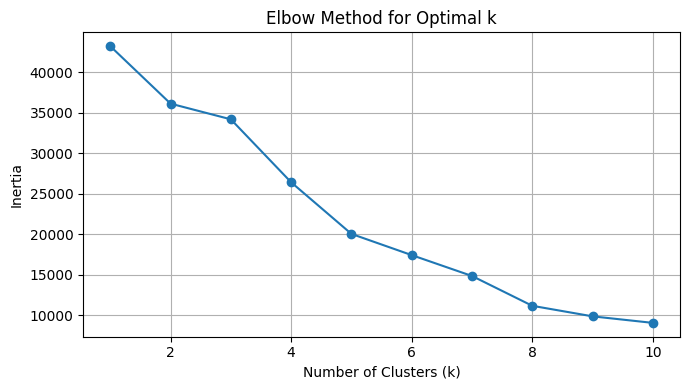

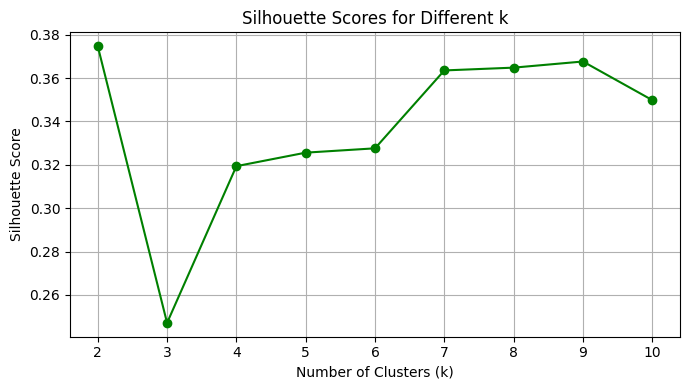

In [53]:
X = scaled_df_clean[['AssetID_8341', 'AssetID_8342', 'AssetID_8343', 'AssetID_8344',
       'AssetID_8346', 'AssetID_9286', 'AssetID_9287']]

# Elbow Method
inertias = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(k_range, inertias, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.tight_layout()
plt.show()

# Silhouette Scores
silhouette_scores = []
k_range_sil = range(2, 11)
for k in k_range_sil:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(7, 4))
plt.plot(k_range_sil, silhouette_scores, marker='o', color='green')
plt.title('Silhouette Scores for Different k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.tight_layout()
plt.show()


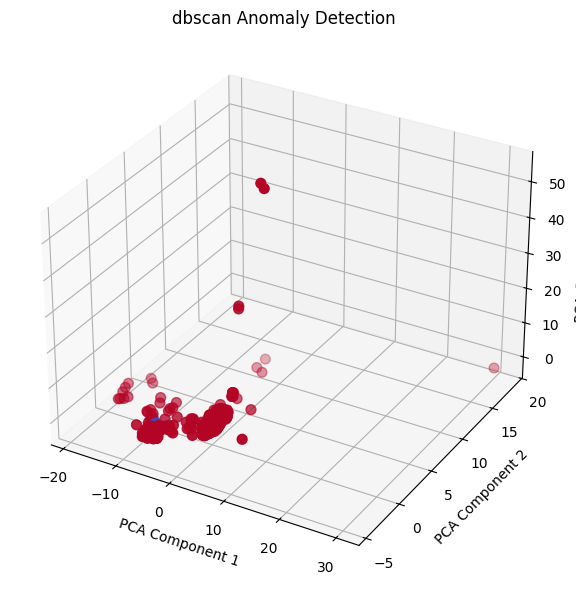

In [54]:
# اجرای DBSCAN روی داده‌های استانداردشده
dbscan = DBSCAN(eps=0.7, min_samples=6)
labels = dbscan.fit_predict(scaled_df_clean)

# کاهش ابعاد داده‌ها به سه مؤلفه اصلی با PCA
pca = PCA(n_components=3)
pca_result = pca.fit_transform(scaled_df_clean)

# رسم داده‌ها با رنگ‌بندی بر اساس برچسب‌های LOF در فضای سه‌بعدی
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    pca_result[:, 0],
    pca_result[:, 1],
    pca_result[:, 2],
    c=[0 if label == 1 else 1 for label in labels],  # 0 = normal, 1 = abnormal
    cmap='coolwarm',
    s=50
)

ax.set_title('dbscan Anomaly Detection')
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')
plt.tight_layout()
plt.show()


In [55]:
from sklearn.metrics import pairwise_distances_argmin_min
import numpy as np
import pandas as pd

# نقاط نرمال (label = 0)
normal_points = scaled_df_clean[labels != -1]
# نقاط غیرعادی (label = -1)
anomaly_indices = scaled_df_clean.index[labels == -1]
anomalies = scaled_df_clean.loc[anomaly_indices]


# محاسبه مرکز ثقل خوشه‌ها
unique_labels = set(labels) - {-1}
centroids = np.array([scaled_df_clean[labels == label].mean(axis=0) for label in unique_labels])

# محاسبه فاصله هر anomaly از نزدیک‌ترین مرکز خوشه
_, distances = pairwise_distances_argmin_min(anomalies, centroids)

# انتخاب مهم‌ترین موارد غیرعادی بر اساس بیشترین فاصله
top_n = 10
top_anomalies_idx_in_anomalies = distances.argsort()[::-1][:top_n]
important_anomalies = anomalies.iloc[top_anomalies_idx_in_anomalies]

# بازگردانی مقادیر اصلی از حالت نرمال‌شده
important_anomalies_original = scaler.inverse_transform(important_anomalies)

# تبدیل به دیتافریم با ستون‌های اصلی و اضافه کردن فاصله از مرکز خوشه
important_anomalies_df = pd.DataFrame(
    important_anomalies_original,
    columns=scaled_df_clean.columns, # Use scaled_df_clean.columns as anomalies is derived from it
    index=important_anomalies.index
)
important_anomalies_df['distance_from_centroid'] = distances[top_anomalies_idx_in_anomalies]


# نمایش خروجی نهایی
print(important_anomalies_df)

      AssetID_8341  AssetID_8342  AssetID_8343  AssetID_8344  AssetID_8346  \
356           0.29          12.2          65.0        -205.0           7.8   
580           0.25          12.2          71.0        -205.0           7.8   
573           0.28          12.2          73.0        -200.0          78.0   
936           0.25          12.0          64.0        -200.0           7.8   
685           0.25          12.2          64.0        -200.0           7.8   
291           0.32          12.3          64.0        -210.0           7.8   
4874          0.00           0.0          39.0           0.0           0.0   
4880          0.00           0.0          46.0         -20.0           0.0   
4884          0.76           0.0          29.0        -180.0           0.0   
4883          0.66           0.0          29.0        -180.0           0.0   

      AssetID_9286  AssetID_9287  distance_from_centroid  
356            8.0        138.00               54.807952  
580            8.0     

In [56]:
from sklearn.metrics import pairwise_distances_argmin_min
import numpy as np
import pandas as pd

# استخراج نقاط غیرعادی
anomalies = scaled_df_clean[labels == -1]

# اضافه کردن برچسب خوشه به دیتافریم استانداردشده
scaled_df_clean['dbscan_label'] = labels

# انتخاب فقط ستون‌های عددی برای محاسبه مرکز ثقل
numeric_cols = scaled_df_clean.select_dtypes(include=np.number).columns.tolist()
# حذف ستون های برچسب گذاری که عددی هستند اما برای خوشه بندی استفاده نشده اند
if 'dbscan_label' in numeric_cols:
    numeric_cols.remove('dbscan_label')
if 'anomaly_label' in numeric_cols:
    numeric_cols.remove('anomaly_label')


# محاسبه مرکز ثقل خوشه‌ها (بدون در نظر گرفتن نقاط غیرعادی)
unique_labels = set(labels) - {-1}
centroids = np.array([scaled_df_clean[scaled_df_clean['dbscan_label'] == label][numeric_cols].mean(axis=0) for label in unique_labels])


# محاسبه فاصله هر anomaly از نزدیک‌ترین مرکز خوشه
# اطمینان از اینکه anomalies فقط شامل ستون‌های عددی است
anomalies_numeric = anomalies[numeric_cols]
_, distances = pairwise_distances_argmin_min(anomalies_numeric, centroids)


# مرتب‌سازی بر اساس فاصله (نزولی)
sorted_idx = distances.argsort()[::-1]
sorted_anomalies_scaled = anomalies.iloc[sorted_idx]
sorted_distances = distances[sorted_idx]

# بازگردانی مقادیر اصلی از حالت نرمال‌شده
# اطمینان از اینکه anomalies_original فقط شامل ستون‌های عددی است
anomalies_original_numeric = scaler.inverse_transform(anomalies[numeric_cols])

# ساخت دیتافریم نهایی با مقادیر اصلی و فاصله از مرکز خوشه
anomalies_df = pd.DataFrame(
    anomalies_original_numeric,
    columns=numeric_cols, # استفاده از نام ستون های عددی
    index=sorted_anomalies_scaled.index # استفاده از ایندکس نمونه‌های مرتب شده
)
anomalies_df['distance_from_centroid'] = sorted_distances

# نمایش خروجی
print(anomalies_df)

      AssetID_8341  AssetID_8342  AssetID_8343  AssetID_8344  AssetID_8346  \
356           0.21         12.30          62.0        -205.0          0.00   
580           0.20         13.30          67.0        -205.0          7.80   
573           0.22         11.80          47.5        -230.0          0.00   
936           0.26         11.70          39.0        -240.0          0.00   
685           0.24         11.70          39.0        -240.0          0.00   
...            ...           ...           ...           ...           ...   
50            0.60         12.30          68.0        -250.0          6.80   
3574          0.12          1.21          68.0        -230.0          6.80   
49            0.09         12.10          50.0        -220.0          0.00   
3019          0.12         12.00          60.0        -230.0          7.00   
47            0.20         11.90          69.0        -230.0          1.28   

      AssetID_9286  AssetID_9287  distance_from_centroid  
356 

In [57]:
# انتخاب مواردی که فاصله‌شان از مرکز خوشه‌ها بیشتر از آستانه مشخصی است
threshold = np.percentile(distances, 90)  # مثلاً ۱۰٪ بالاترین فاصله‌ها
selected_idx = np.where(distances > threshold)[0]
selected_anomalies = anomalies.iloc[selected_idx]
selected_anomalies_original = scaler.inverse_transform(selected_anomalies)

selected_df = pd.DataFrame(
    selected_anomalies_original,
    columns=data_to_scale.columns, # Use the original numerical column names
    index=selected_anomalies.index
)
selected_df['distance_from_centroid'] = distances[selected_idx]

print("Selected anomalies based on distance threshold:")
print(selected_df)

Selected anomalies based on distance threshold:
      AssetID_8341  AssetID_8342  AssetID_8343  AssetID_8344  AssetID_8346  \
291           0.32          12.3          64.0        -210.0           7.8   
356           0.29          12.2          65.0        -205.0           7.8   
573           0.28          12.2          73.0        -200.0          78.0   
580           0.25          12.2          71.0        -205.0           7.8   
685           0.25          12.2          64.0        -200.0           7.8   
936           0.25          12.0          64.0        -200.0           7.8   
4874          0.00           0.0          39.0           0.0           0.0   
4880          0.00           0.0          46.0         -20.0           0.0   
4883          0.66           0.0          29.0        -180.0           0.0   
4884          0.76           0.0          29.0        -180.0           0.0   

      AssetID_9286  AssetID_9287  distance_from_centroid  
291            8.0         64.00  

In [58]:
anomalies_df.to_excel('all_anomalies_sorted.xlsx')
# یا
anomalies_df.to_html('all_anomalies_sorted.html')


In [59]:
import pandas as pd

# بازگردانی مقادیر اصلی از حالت نرمالایز
important_anomalies_original = scaler.inverse_transform(important_anomalies)

# تبدیل به دیتافریم با ستون‌های اصلی
important_anomalies_df = pd.DataFrame(
    important_anomalies_original,
    columns=data_to_scale.columns, # Use original column names
    index=important_anomalies.index
)

# نمایش خروجی
print(important_anomalies_df)

      AssetID_8341  AssetID_8342  AssetID_8343  AssetID_8344  AssetID_8346  \
356           0.29          12.2          65.0        -205.0           7.8   
580           0.25          12.2          71.0        -205.0           7.8   
573           0.28          12.2          73.0        -200.0          78.0   
936           0.25          12.0          64.0        -200.0           7.8   
685           0.25          12.2          64.0        -200.0           7.8   
291           0.32          12.3          64.0        -210.0           7.8   
4874          0.00           0.0          39.0           0.0           0.0   
4880          0.00           0.0          46.0         -20.0           0.0   
4884          0.76           0.0          29.0        -180.0           0.0   
4883          0.66           0.0          29.0        -180.0           0.0   

      AssetID_9286  AssetID_9287  
356            8.0        138.00  
580            8.0        136.00  
573            8.1          1.37  
9

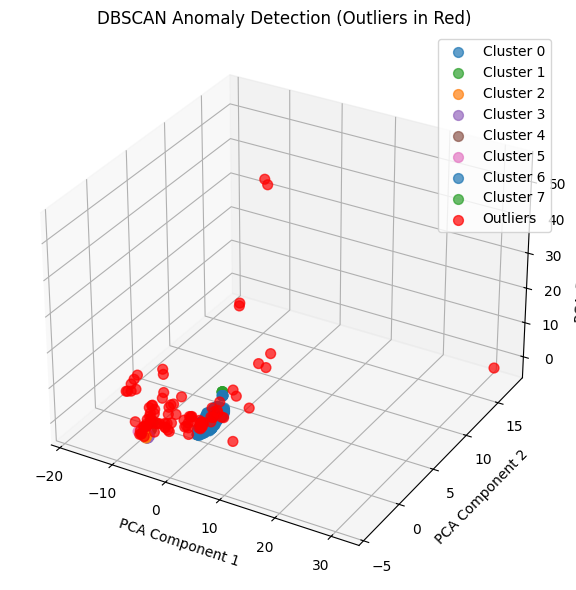

In [60]:
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# اجرای DBSCAN روی داده‌های استانداردشده
dbscan = DBSCAN(eps=0.7, min_samples=6)
labels = dbscan.fit_predict(scaled_df_clean)

# کاهش ابعاد داده‌ها به سه مؤلفه اصلی با PCA
pca = PCA(n_components=3)
pca_result = pca.fit_transform(scaled_df_clean)

# تعریف رنگ‌ها: خوشه‌ها با رنگ‌های مختلف، نویز (outliers) با رنگ قرمز
colors = ['tab:blue', 'tab:green', 'tab:orange', 'tab:purple', 'tab:brown', 'tab:pink']
outlier_color = 'red'

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

for label in set(labels):
    color = outlier_color if label == -1 else colors[label % len(colors)]
    mask = labels == label
    ax.scatter(
        pca_result[mask, 0],
        pca_result[mask, 1],
        pca_result[mask, 2],
        c=color,
        label=f'Cluster {label}' if label != -1 else 'Outliers',
        s=50,
        alpha=0.7
    )

ax.set_title('DBSCAN Anomaly Detection (Outliers in Red)')
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')
ax.legend()
plt.tight_layout()
plt.show()


In [61]:
# !pip freeze > requirements.txt

Normal points: 7114
Outliers: 93


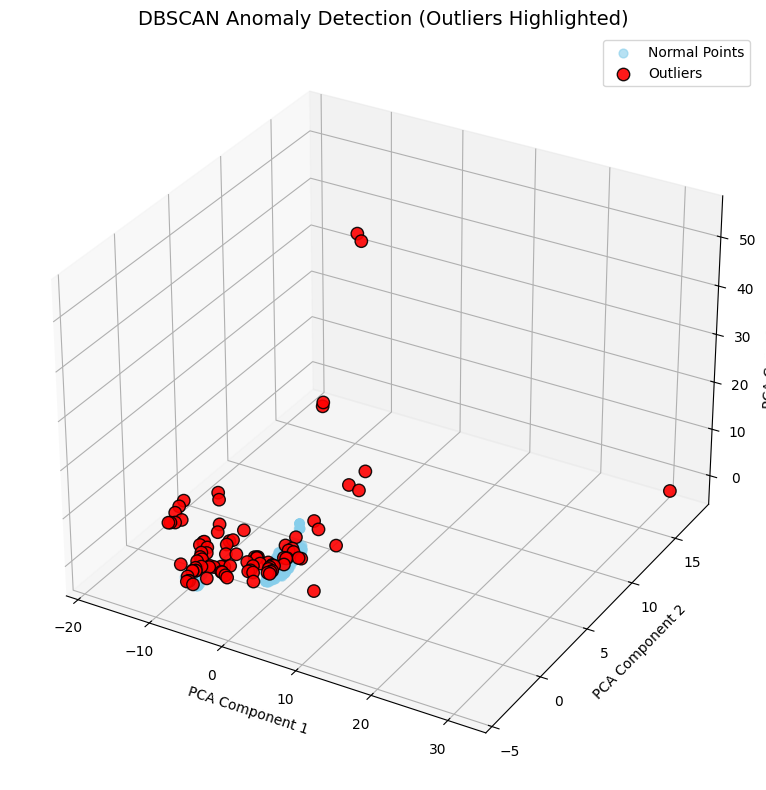

In [62]:
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# اجرای DBSCAN روی داده‌های استانداردشده
dbscan = DBSCAN(eps=0.7, min_samples=6)
labels = dbscan.fit_predict(scaled_df_clean)

# شمارش نقاط نرمال و نقاط پرت
n_outliers = np.sum(labels == -1)
n_core = np.sum(labels != -1)
print(f"Normal points: {n_core}")
print(f"Outliers: {n_outliers}")

# کاهش ابعاد داده‌ها به سه مؤلفه اصلی با PCA
pca = PCA(n_components=3)
pca_result = pca.fit_transform(scaled_df_clean)

# رسم داده‌ها با رنگ‌بندی و جداسازی واضح
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# نقاط نرمال (خوشه‌ها)
core_mask = labels != -1
ax.scatter(
    pca_result[core_mask, 0],
    pca_result[core_mask, 1],
    pca_result[core_mask, 2],
    c='skyblue',
    label='Normal Points',
    s=40,
    alpha=0.6
)

# نقاط پرت (outliers)
outlier_mask = labels == -1
ax.scatter(
    pca_result[outlier_mask, 0],
    pca_result[outlier_mask, 1],
    pca_result[outlier_mask, 2],
    c='red',
    label='Outliers',
    s=80,
    alpha=0.9,
    edgecolors='black'
)

ax.set_title('DBSCAN Anomaly Detection (Outliers Highlighted)', fontsize=14)
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')
ax.legend()
plt.tight_layout()
plt.show()


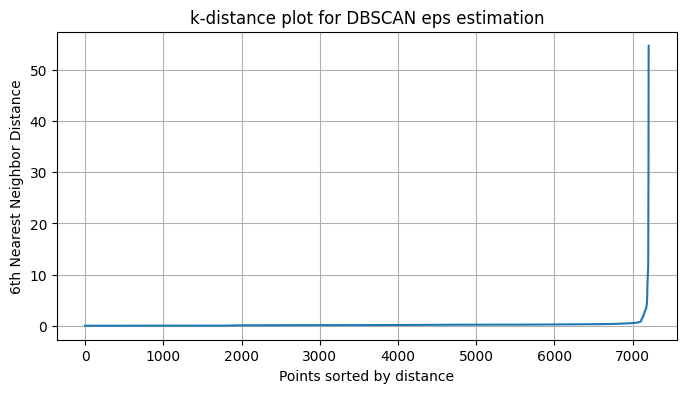

In [63]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

# Choose min_samples (e.g., 6)
min_samples = 6
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(scaled_df_clean)
distances, indices = neighbors_fit.kneighbors(scaled_df_clean)

# Sort and plot the k-distances
k_distances = np.sort(distances[:, -1])
plt.figure(figsize=(8, 4))
plt.plot(k_distances)
plt.title('k-distance plot for DBSCAN eps estimation')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{min_samples}th Nearest Neighbor Distance')
plt.grid(True)
plt.show()


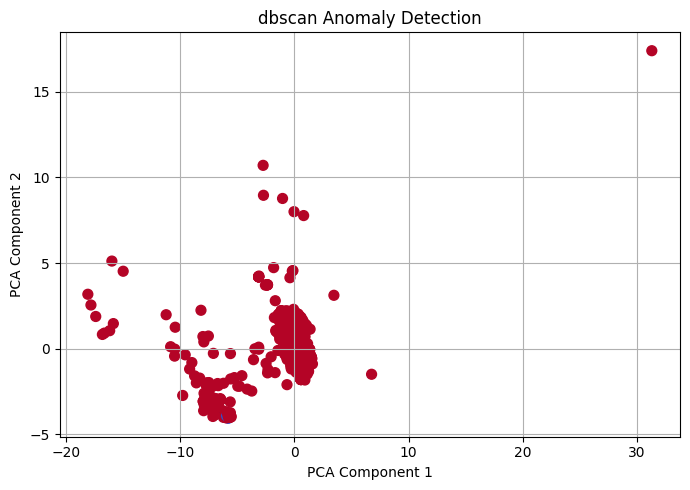

درصد ناهنجاری‌ها: 1.60%
تعداد داده‌ها در هر خوشه:
Noise (abnormal): 115 مورد
Cluster 0: 7015 مورد
Cluster 1: 10 مورد
Cluster 2: 33 مورد
Cluster 3: 17 مورد
Cluster 4: 17 مورد


In [64]:
# اجرای DBSCAN روی داده‌های استانداردشده
dbscan = DBSCAN(eps=0.7, min_samples=9)
labels = dbscan.fit_predict(scaled_df_clean)

# کاهش ابعاد داده‌ها به دو مؤلفه اصلی با PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_df_clean)

# رسم داده‌ها با رنگ‌بندی بر اساس برچسب‌های LOF
plt.figure(figsize=(7, 5))
plt.scatter(
    pca_result[:, 0],
    pca_result[:, 1],
    c=[0 if label == 1 else 1 for label in labels],  # 0 = normal, 1 = abnormal
    cmap='coolwarm',
    s=50
)
plt.title('dbscan Anomaly Detection')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(True)
plt.tight_layout()
plt.show()

num_abnormal = np.sum(labels == -1)
num_total = len(labels)
print(f"درصد ناهنجاری‌ها: {100 * num_abnormal / num_total:.2f}%")

# ساخت یک سری از برچسب‌های خوشه
cluster_series = pd.Series(labels)

# شمارش تعداد اعضای هر خوشه
cluster_counts = cluster_series.value_counts().sort_index()

# نمایش نتایج
print("تعداد داده‌ها در هر خوشه:")
for cluster_id, count in cluster_counts.items():
    label = f"Cluster {cluster_id}" if cluster_id != -1 else "Noise (abnormal)"
    print(f"{label}: {count} مورد")


In [65]:
from sklearn.metrics import davies_bouldin_score
from sklearn.cluster import DBSCAN
import numpy as np

best_score = float("inf")  # چون مقدار کمتر بهتره
best_params = None

for eps in np.arange(0.3, 1.2, 0.1):
    for min_samples in range(4, 10):
        db = DBSCAN(eps=eps, min_samples=min_samples).fit(scaled_df_clean)
        labels = db.labels_

        unique_labels = set(labels)
        if -1 in unique_labels:
            unique_labels.remove(-1)
        if len(unique_labels) > 1:
            # حذف نقاط نویز برای محاسبه شاخص
            core_samples_mask = labels != -1
            core_labels = labels[core_samples_mask]
            scaled_df_clean_filtered = scaled_df_clean[core_samples_mask]

            score = davies_bouldin_score(scaled_df_clean_filtered, core_labels)
            if score < best_score:
                best_score = score
                best_params = (eps, min_samples)
            print(f"eps={eps:.1f}, min_samples={min_samples} → DB Index={score:.3f}")

print(f"\nBest Davies-Bouldin Index: {best_score:.3f}")
print(f"Optimal eps: {best_params[0]:.1f}, min_samples: {best_params[1]}")


eps=0.3, min_samples=4 → DB Index=0.793
eps=0.3, min_samples=5 → DB Index=0.723
eps=0.3, min_samples=6 → DB Index=0.840
eps=0.3, min_samples=7 → DB Index=0.868
eps=0.3, min_samples=8 → DB Index=0.953
eps=0.3, min_samples=9 → DB Index=0.868
eps=0.4, min_samples=4 → DB Index=0.744
eps=0.4, min_samples=5 → DB Index=0.719
eps=0.4, min_samples=6 → DB Index=0.727
eps=0.4, min_samples=7 → DB Index=0.764
eps=0.4, min_samples=8 → DB Index=0.851
eps=0.4, min_samples=9 → DB Index=0.860
eps=0.5, min_samples=4 → DB Index=0.734
eps=0.5, min_samples=5 → DB Index=0.782
eps=0.5, min_samples=6 → DB Index=0.781
eps=0.5, min_samples=7 → DB Index=0.776
eps=0.5, min_samples=8 → DB Index=0.920
eps=0.5, min_samples=9 → DB Index=1.013
eps=0.6, min_samples=4 → DB Index=0.412
eps=0.6, min_samples=5 → DB Index=0.411
eps=0.6, min_samples=6 → DB Index=0.437
eps=0.6, min_samples=7 → DB Index=0.432
eps=0.6, min_samples=8 → DB Index=0.529
eps=0.6, min_samples=9 → DB Index=0.528
eps=0.7, min_samples=4 → DB Index=0.241


In [66]:
from sklearn.metrics import davies_bouldin_score
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
import numpy as np

# Re-perform DBSCAN and PCA within this cell
dbscan = DBSCAN(eps=0.7, min_samples=4) # Using the best params found earlier
labels = dbscan.fit_predict(scaled_df_clean)

# Reduce dimensions with PCA for visualization and analysis
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_df_clean)

# Filter for normal data (labels ≠ -1)
mask = labels != -1
pca_filtered = pca_result[mask]
labels_filtered = labels[mask]

# Calculate Davies-Bouldin Index on the normal data (excluding noise points)
if len(np.unique(labels_filtered)) > 1: # Ensure there's more than one cluster
    db_index = davies_bouldin_score(pca_filtered, labels_filtered)

    # Display the index value
    print(f"Davies-Bouldin Index for DBSCAN clusters (excluding noise points): {db_index:.2f}")
else:
    print("Cannot calculate Davies-Bouldin Index: Less than two clusters found after removing noise.")

Davies-Bouldin Index for DBSCAN clusters (excluding noise points): 0.65


In [67]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np

best_score = -1
best_params = None

for eps in [0.3,0.4,0.5,0.6,0.7,0.8,0.9,1,1.1,1.2]:
    for min_samples in [3,4,5,6,9]:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(scaled_df_clean)

        # فقط نقاط نرمال را برای سیلوئت در نظر بگیر
        mask = labels != -1
        if len(set(labels[mask])) > 1:
            score = silhouette_score(scaled_df_clean[mask], labels[mask])
            print(f"eps={eps}, min_samples={min_samples} → silhouette={score:.3f}")
            if score > best_score:
                best_score = score
                best_params = (eps, min_samples)

print(f"\n✅ بهترین ترکیب: eps={best_params[0]}, min_samples={best_params[1]} با نمره سیلوئت {best_score:.3f}")


eps=0.3, min_samples=3 → silhouette=-0.191
eps=0.3, min_samples=4 → silhouette=-0.151
eps=0.3, min_samples=5 → silhouette=-0.108
eps=0.3, min_samples=6 → silhouette=-0.105
eps=0.3, min_samples=9 → silhouette=0.004
eps=0.4, min_samples=3 → silhouette=-0.241
eps=0.4, min_samples=4 → silhouette=-0.236
eps=0.4, min_samples=5 → silhouette=-0.165
eps=0.4, min_samples=6 → silhouette=-0.143
eps=0.4, min_samples=9 → silhouette=-0.173
eps=0.5, min_samples=3 → silhouette=-0.239
eps=0.5, min_samples=4 → silhouette=-0.234
eps=0.5, min_samples=5 → silhouette=-0.125
eps=0.5, min_samples=6 → silhouette=-0.129
eps=0.5, min_samples=9 → silhouette=-0.132
eps=0.6, min_samples=3 → silhouette=0.301
eps=0.6, min_samples=4 → silhouette=0.400
eps=0.6, min_samples=5 → silhouette=0.400
eps=0.6, min_samples=6 → silhouette=0.400
eps=0.6, min_samples=9 → silhouette=0.400
eps=0.7, min_samples=3 → silhouette=0.221
eps=0.7, min_samples=4 → silhouette=0.744
eps=0.7, min_samples=5 → silhouette=0.744
eps=0.7, min_samples

In [68]:
from sklearn.metrics import calinski_harabasz_score

best_score = -1
best_params = None

for eps in np.arange(0.3, 1.2, 0.1):
    for min_samples in range(4, 10):
        db = DBSCAN(eps=eps, min_samples=min_samples).fit(scaled_df_clean)
        labels = db.labels_

        unique_labels = set(labels)
        if -1 in unique_labels:
            unique_labels.remove(-1)
        if len(unique_labels) > 1:
            # حذف نقاط نویز برای محاسبه شاخص
            core_samples_mask = labels != -1
            core_labels = labels[core_samples_mask]
            scaled_df_clean_filtered = scaled_df_clean[core_samples_mask]

            score = calinski_harabasz_score(scaled_df_clean_filtered, core_labels)
            if score > best_score:
                best_score = score
                best_params = (eps, min_samples)
            print(f"eps={eps:.1f}, min_samples={min_samples} → CH Score={score:.2f}")

print(f"\nBest Calinski-Harabasz Score: {best_score:.2f}")
print(f"Optimal eps: {best_params[0]:.1f}, min_samples: {best_params[1]}")


eps=0.3, min_samples=4 → CH Score=517.72
eps=0.3, min_samples=5 → CH Score=716.08
eps=0.3, min_samples=6 → CH Score=717.76
eps=0.3, min_samples=7 → CH Score=900.16
eps=0.3, min_samples=8 → CH Score=933.77
eps=0.3, min_samples=9 → CH Score=1321.77
eps=0.4, min_samples=4 → CH Score=505.23
eps=0.4, min_samples=5 → CH Score=593.04
eps=0.4, min_samples=6 → CH Score=683.82
eps=0.4, min_samples=7 → CH Score=709.62
eps=0.4, min_samples=8 → CH Score=687.09
eps=0.4, min_samples=9 → CH Score=770.67
eps=0.5, min_samples=4 → CH Score=570.09
eps=0.5, min_samples=5 → CH Score=827.61
eps=0.5, min_samples=6 → CH Score=827.36
eps=0.5, min_samples=7 → CH Score=809.65
eps=0.5, min_samples=8 → CH Score=893.39
eps=0.5, min_samples=9 → CH Score=966.54
eps=0.6, min_samples=4 → CH Score=1056.05
eps=0.6, min_samples=5 → CH Score=1051.35
eps=0.6, min_samples=6 → CH Score=1167.19
eps=0.6, min_samples=7 → CH Score=1163.85
eps=0.6, min_samples=8 → CH Score=1434.29
eps=0.6, min_samples=9 → CH Score=1439.33
eps=0.7, 

In [69]:
# اجرای DBSCAN روی داده‌های استانداردشده
dbscan = DBSCAN(eps=0.6, min_samples=9) # Using the best params found earlier
labels = dbscan.fit_predict(scaled_df_clean)

# اضافه کردن برچسب خوشه به دیتافریم استانداردشده
scaled_df_clean['dbscan_label'] = labels

# افزودن برچسب DBSCAN به دیتافریم اصلی با استفاده از ایندکس
df1 = df1.merge(scaled_df_clean[['dbscan_label']], left_index=True, right_index=True, how='left')

# فیلتر کردن نمونه‌های غیرنرمال (برچسب -1)
abnormal_df = df1[df1['dbscan_label'] == -1]

# انتخاب ۱۰ نمونه تصادفی از موارد غیرنرمال
abnormal_sample = abnormal_df.sample(n=10, random_state=42).reset_index(drop=True)

# نمایش جدول نهایی
print("🔍 ۱۰ نمونه از داده‌های غیرنرمال شناسایی‌شده توسط DBSCAN (با مقادیر واقعی):")
print(abnormal_sample)

🔍 ۱۰ نمونه از داده‌های غیرنرمال شناسایی‌شده توسط DBSCAN (با مقادیر واقعی):
   AssetID_8341  AssetID_8342  AssetID_8343  AssetID_8344  AssetID_8346  \
0          0.43          12.4          74.0        -230.0           7.0   
1          0.07          11.9          59.0        -260.0           7.5   
2          1.41          12.0          70.0        -200.0           7.8   
3          0.90          11.9          68.0        -220.0           6.8   
4          0.23          11.3          62.0        -245.0           7.7   
5          0.23          11.3          65.0        -220.0           7.8   
6          0.22          11.6          38.0        -260.0           0.0   
7          0.10          11.4          34.0        -260.0           0.0   
8          0.23          11.9          67.0        -200.0           6.9   
9          0.30          11.5          33.0        -265.0           0.0   

   AssetID_9286  AssetID_9287                date  dbscan_label  
0           7.2          1.28 202

In [70]:
from sklearn.cluster import DBSCAN
import pandas as pd

# اجرای DBSCAN روی داده‌های استانداردشده
dbscan = DBSCAN(eps=0.7, min_samples=9)
labels = dbscan.fit_predict(scaled_df_clean)

# افزودن برچسب خوشه به دیتافریم استانداردشده
scaled_df_clean['dbscan_label'] = labels

# افزودن برچسب DBSCAN به دیتافریم اصلی با استفاده از ایندکس
df1 = df1.merge(scaled_df_clean[['dbscan_label']], left_index=True, right_index=True, how='left', suffixes=('', '_y'))

# حذف ستون‌های تکراری در صورت وجود
df1 = df1.loc[:, ~df1.columns.duplicated()]

# فیلتر کردن نمونه‌های غیرنرمال (برچسب -1)
abnormal_df = df1[df1['dbscan_label'] == -1]

# انتخاب ۱۰ نمونه تصادفی از موارد غیرنرمال
abnormal_sample = abnormal_df.sample(n=10, random_state=42).reset_index(drop=True)

# حذف ستون برچسب DBSCAN
abnormal_sample = abnormal_sample.drop(columns=['dbscan_label'])

# نمایش جدول نهایی به‌صورت یکپارچه
pd.set_option('display.max_columns', None)  # نمایش تمام ستون‌ها
pd.set_option('display.width', None)        # جلوگیری از شکستن خطوط
print("🔍 ۱۰ نمونه از داده‌های غیرنرمال شناسایی‌شده توسط DBSCAN (با مقادیر واقعی):")
print(abnormal_sample)


🔍 ۱۰ نمونه از داده‌های غیرنرمال شناسایی‌شده توسط DBSCAN (با مقادیر واقعی):
   AssetID_8341  AssetID_8342  AssetID_8343  AssetID_8344  AssetID_8346  \
0          0.43          12.4          74.0        -230.0           7.0   
1          0.07          11.9          59.0        -260.0           7.5   
2          1.41          12.0          70.0        -200.0           7.8   
3          0.90          11.9          68.0        -220.0           6.8   
4          0.23          11.3          62.0        -245.0           7.7   
5          0.23          11.3          65.0        -220.0           7.8   
6          0.22          11.6          38.0        -260.0           0.0   
7          0.10          11.4          34.0        -260.0           0.0   
8          0.23          11.9          67.0        -200.0           6.9   
9          0.30          11.5          33.0        -265.0           0.0   

   AssetID_9286  AssetID_9287                date  dbscan_label_y  
0           7.2          1.28 2

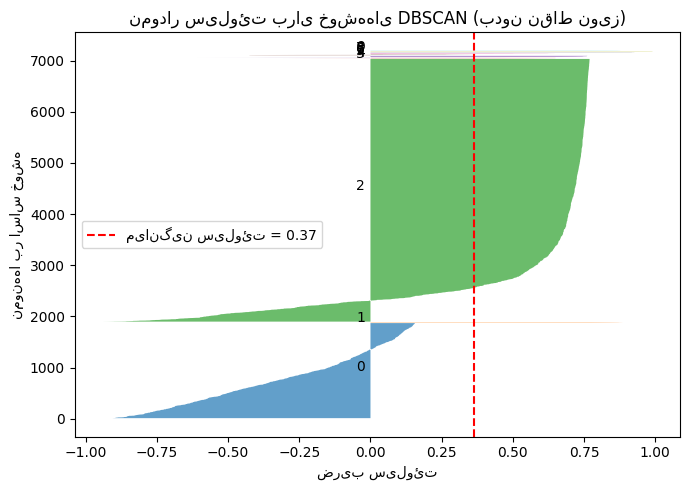

In [71]:
# اجرای DBSCAN روی داده‌های استانداردشده
dbscan = DBSCAN(eps=0.7, min_samples=4)
labels = dbscan.fit_predict(scaled_df_clean)

# کاهش ابعاد با PCA برای نمایش و تحلیل
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_df_clean)

# فیلتر کردن داده‌های نرمال (برچسب ≠ -1)
mask = labels != -1
pca_filtered = pca_result[mask]
labels_filtered = labels[mask]

# محاسبه نمرات سیلوئت
silhouette_vals = silhouette_samples(pca_filtered, labels_filtered)
silhouette_avg = silhouette_score(pca_filtered, labels_filtered)

# رسم نمودار سیلوئت
plt.figure(figsize=(7, 5))
y_lower = 10
for i in np.unique(labels_filtered):
    ith_cluster_silhouette_vals = silhouette_vals[labels_filtered == i]
    ith_cluster_silhouette_vals.sort()
    size_cluster_i = ith_cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster_i

    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_cluster_silhouette_vals,
        alpha=0.7
    )
    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

plt.axvline(x=silhouette_avg, color="red", linestyle="--", label=f"میانگین سیلوئت = {silhouette_avg:.2f}")
plt.xlabel("ضریب سیلوئت")
plt.ylabel("نمونه‌ها بر اساس خوشه")
plt.title("نمودار سیلوئت برای خوشه‌های DBSCAN (بدون نقاط نویز)")
plt.legend()
plt.tight_layout()
plt.show()

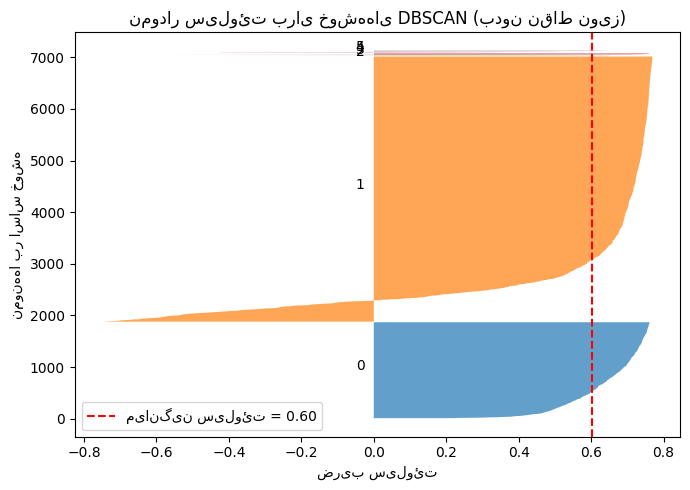

In [72]:
# اجرای DBSCAN روی داده‌های استانداردشده
dbscan = DBSCAN(eps=0.7, min_samples=9)
labels = dbscan.fit_predict(scaled_df_clean)

# کاهش ابعاد با PCA برای نمایش و تحلیل
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_df_clean)

# فیلتر کردن داده‌های نرمال (برچسب ≠ -1)
mask = labels != -1
pca_filtered = pca_result[mask]
labels_filtered = labels[mask]

# محاسبه نمرات سیلوئت
silhouette_vals = silhouette_samples(pca_filtered, labels_filtered)
silhouette_avg = silhouette_score(pca_filtered, labels_filtered)

# رسم نمودار سیلوئت
plt.figure(figsize=(7, 5))
y_lower = 10
for i in np.unique(labels_filtered):
    ith_cluster_silhouette_vals = silhouette_vals[labels_filtered == i]
    ith_cluster_silhouette_vals.sort()
    size_cluster_i = ith_cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster_i

    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_cluster_silhouette_vals,
        alpha=0.7
    )
    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

plt.axvline(x=silhouette_avg, color="red", linestyle="--", label=f"میانگین سیلوئت = {silhouette_avg:.2f}")
plt.xlabel("ضریب سیلوئت")
plt.ylabel("نمونه‌ها بر اساس خوشه")
plt.title("نمودار سیلوئت برای خوشه‌های DBSCAN (بدون نقاط نویز)")
plt.legend()
plt.tight_layout()
plt.show()

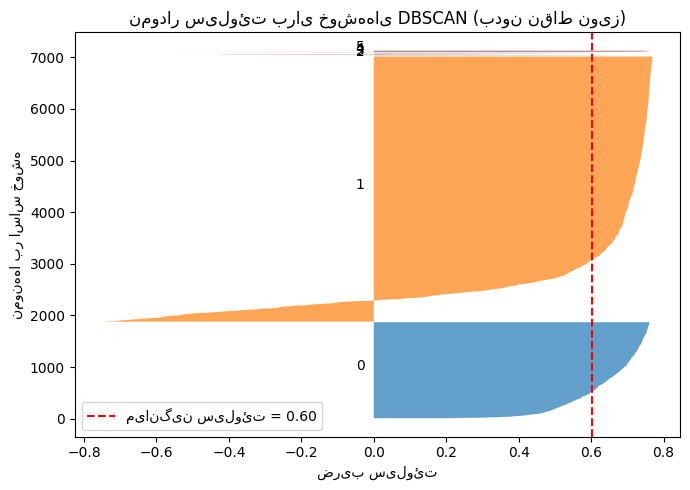

In [73]:
# اجرای DBSCAN روی داده‌های استانداردشده
dbscan = DBSCAN(eps=0.6, min_samples=9)
labels = dbscan.fit_predict(scaled_df_clean)

# کاهش ابعاد با PCA برای نمایش و تحلیل
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_df_clean)

# فیلتر کردن داده‌های نرمال (برچسب ≠ -1)
mask = labels != -1
pca_filtered = pca_result[mask]
labels_filtered = labels[mask]

# محاسبه نمرات سیلوئت
silhouette_vals = silhouette_samples(pca_filtered, labels_filtered)
silhouette_avg = silhouette_score(pca_filtered, labels_filtered)

# رسم نمودار سیلوئت
plt.figure(figsize=(7, 5))
y_lower = 10
for i in np.unique(labels_filtered):
    ith_cluster_silhouette_vals = silhouette_vals[labels_filtered == i]
    ith_cluster_silhouette_vals.sort()
    size_cluster_i = ith_cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster_i

    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_cluster_silhouette_vals,
        alpha=0.7
    )
    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

plt.axvline(x=silhouette_avg, color="red", linestyle="--", label=f"میانگین سیلوئت = {silhouette_avg:.2f}")
plt.xlabel("ضریب سیلوئت")
plt.ylabel("نمونه‌ها بر اساس خوشه")
plt.title("نمودار سیلوئت برای خوشه‌های DBSCAN (بدون نقاط نویز)")
plt.legend()
plt.tight_layout()
plt.show()